In [1]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.


In [2]:
import os
import pandas as pd

# List contents of the downloaded directory
print(os.listdir(path))

# Assuming the CSV file is named 'healthcare-dataset-stroke-data.csv' based on the dataset name
csv_file_path = os.path.join(path, 'healthcare-dataset-stroke-data.csv')
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

['healthcare-dataset-stroke-data.csv']


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Now let's get a summary of the dataset to understand its structure, data types, and check for missing values.

In [3]:
# Display concise summary of the DataFrame
display(df.info())

# Display descriptive statistics of the DataFrame
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


None

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### Data Preparation for Deep Learning

Now that the data is cleaned and encoded, we will prepare it for our deep learning model:
1. Separate features (X) and target (y).
2. Split the data into training and testing sets.
3. Scale numerical features.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop the 'gender_Other' column if it exists, as it often has very few samples and can cause issues
if 'gender_Other' in df.columns:
    df = df.drop('gender_Other', axis=1)

# Separate features (X) and target (y)
X = df.drop('stroke', axis=1)
y = df['stroke']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify numerical columns for scaling after one-hot encoding
# These are 'age', 'avg_glucose_level', 'bmi'
numerical_cols_to_scale = ['age', 'avg_glucose_level', 'bmi']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features in both training and testing sets
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

display(X_train.head())

Shape of X_train: (4088, 15)
Shape of X_test: (1022, 15)
Shape of y_train: (4088,)
Shape of y_test: (1022,)


,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
845,0.205661,0,0,-0.819973,0.538479,False,True,False,True,False,False,True,False,True,False
3744,-1.254901,0,0,0.352075,-1.020641,True,False,False,True,False,False,False,False,True,False
4183,1.046590,0,0,0.090662,-0.518114,False,True,False,False,True,False,False,False,True,False
3409,0.028623,0,0,-0.903944,-0.531000,True,True,False,True,False,False,True,False,False,True
284,-1.299160,0,0,-0.529834,0.345200,True,False,False,False,False,False,True,False,False,False


### Build and Train the Deep Learning Model

Now we will define, compile, and train our deep learning model using Keras.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

# Define the model architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(), Recall()])

# Display model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9517 - loss: 0.2183 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9425 - val_loss: 0.1831 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9535 - loss: 0.1695 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9425 - val_loss: 0.1786 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9535 - loss: 0.1577 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9425 - val_loss: 0.1810 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9535 - loss: 0.1585 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9425 - val_loss: 0.1821 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 

### Build and Train the Deep Learning Model

Now we will define, compile, and train our deep learning model using Keras.

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

# Define the model architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(), Recall()])

# Display model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9440 - loss: 0.2432 - precision: 0.0811 - recall: 0.0197 - val_accuracy: 0.9425 - val_loss: 0.1865 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9535 - loss: 0.1705 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9425 - val_loss: 0.1862 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9535 - loss: 0.1697 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9425 - val_loss: 0.1735 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9535 - loss: 0.1630 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9425 - val_loss: 0.1736 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9535 - loss: 0.1575 - precision: 0.000

### Evaluate the Model

After training, we evaluate the model's performance on the unseen test data.

In [10]:
# Evaluate the model on the test set
loss, accuracy, precision, recall = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")


Test Loss: 0.2289
Test Accuracy: 0.9413
Test Precision: 0.1875
Test Recall: 0.0600


### Visualize Training History

Let's plot the training and validation loss and accuracy to understand the model's learning process over epochs.

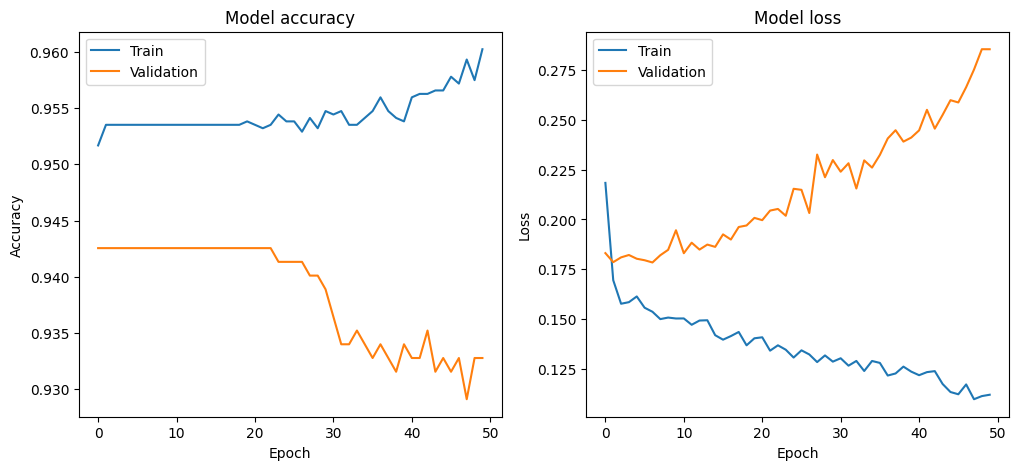

In [11]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


### Evaluate the Model

After training, we evaluate the model's performance on the unseen test data.

In [8]:
# Evaluate the model on the test set
loss, accuracy, precision, recall = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")


Test Loss: 0.2289
Test Accuracy: 0.9413
Test Precision: 0.1875
Test Recall: 0.0600


### Visualize Training History

Let's plot the training and validation loss and accuracy to understand the model's learning process over epochs.

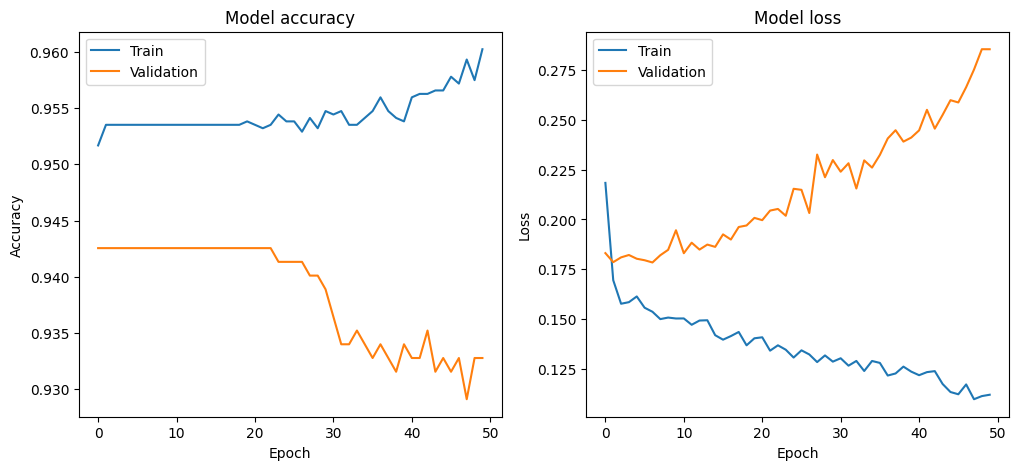

In [9]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


### Addressing Class Imbalance with Class Weights

Given the low precision and recall, the dataset likely suffers from class imbalance. We will calculate class weights and re-train the model with these weights to give more importance to the minority class (stroke cases).

In [13]:
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:", class_weights_dict)

# Re-define and compile the model (using the same architecture)
model_weighted = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

optimizer_weighted = Adam(learning_rate=0.001)
model_weighted.compile(optimizer=optimizer_weighted,
                       loss='binary_crossentropy',
                       metrics=['accuracy', Precision(), Recall()])

print("\nTraining model with class weights...")
# Train the model with class weights
history_weighted = model_weighted.fit(X_train, y_train,
                                       epochs=50,
                                       batch_size=32,
                                       validation_split=0.2,
                                       class_weight=class_weights_dict,
                                       verbose=1)

Calculated Class Weights: {0: np.float64(0.5255849832861919), 1: np.float64(10.271356783919598)}

Training model with class weights...
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7749 - loss: 0.6160 - precision_3: 0.0933 - recall_3: 0.4408 - val_accuracy: 0.7164 - val_loss: 0.4337 - val_precision_3: 0.1483 - val_recall_3: 0.8298
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6957 - loss: 0.5288 - precision_3: 0.1129 - recall_3: 0.8092 - val_accuracy: 0.5892 - val_loss: 0.5987 - val_precision_3: 0.1187 - val_recall_3: 0.9574
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6557 - loss: 0.4967 - precision_3: 0.1053 - recall_3: 0.8553 - val_accuracy: 0.5966 - val_loss: 0.6017 - val_precision_3: 0.1165 - val_recall_3: 0.9149
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6606 - loss: 0.4823 - precision_3: 0.1118 - recall_3: 0.9079 - val_accuracy: 0.6932 - val_loss: 0.4556 - val_precision_3: 0.1483 - val_recall_3: 0.9149
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6982 - loss: 0.4629 - precision_3: 0.1187 - recall_3: 0.8553 - val_accura

### Evaluate the Weighted Model

Now, let's evaluate the performance of the model trained with class weights on the test set.

In [22]:
# Evaluate the weighted model on the test set
loss_weighted, accuracy_weighted, precision_weighted, recall_weighted = model_weighted.evaluate(X_test, y_test, verbose=0)

print(f"Weighted Model Test Loss: {loss_weighted:.4f}")
print(f"Weighted Model Test Accuracy: {accuracy_weighted:.4f}")
print(f"Weighted Model Test Precision: {precision_weighted:.4f}")
print(f"Weighted Model Test Recall: {recall_weighted:.4f}")

# Compare with previous model's results (assuming variables 'accuracy', 'precision', 'recall' are still available)
print("\n--- Comparison with Original Model ---")
print(f"Original Model Test Accuracy: {accuracy:.4f}")
print(f"Original Model Test Precision: {precision:.4f}")
print(f"Original Model Test Recall: {recall:.4f}")

Weighted Model Test Loss: 0.3943
Weighted Model Test Accuracy: 0.7877
Weighted Model Test Precision: 0.1477
Weighted Model Test Recall: 0.7000

--- Comparison with Original Model ---
Original Model Test Accuracy: 0.9413
Original Model Test Precision: 0.1875
Original Model Test Recall: 0.0600


### Visualize Weighted Model Training History

Let's also plot the training and validation loss and accuracy for the weighted model to understand its learning process.

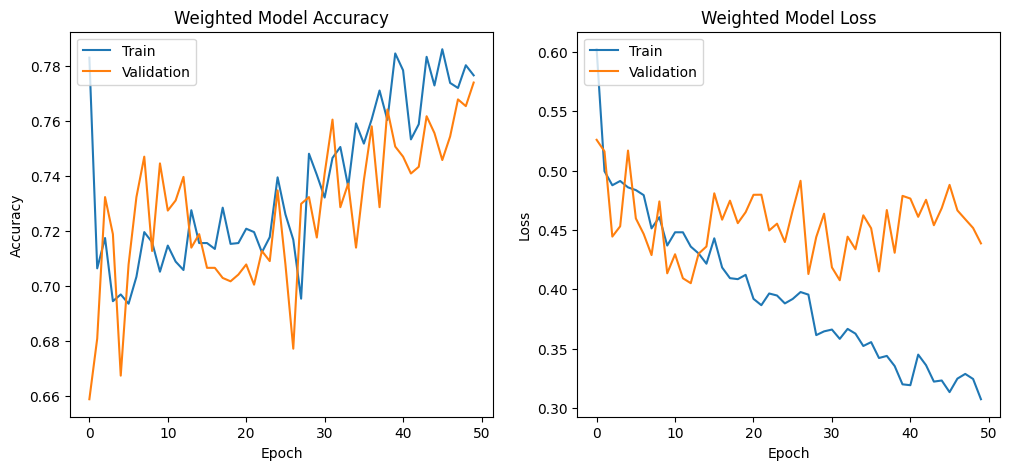

In [23]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for weighted model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_weighted.history['accuracy'])
plt.plot(history_weighted.history['val_accuracy'])
plt.title('Weighted Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for weighted model
plt.subplot(1, 2, 2)
plt.plot(history_weighted.history['loss'])
plt.plot(history_weighted.history['val_loss'])
plt.title('Weighted Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Evaluate the Weighted Model

Now, let's evaluate the performance of the model trained with class weights on the test set.

In [20]:
# Evaluate the weighted model on the test set
loss_weighted, accuracy_weighted, precision_weighted, recall_weighted = model_weighted.evaluate(X_test, y_test, verbose=0)

print(f"Weighted Model Test Loss: {loss_weighted:.4f}")
print(f"Weighted Model Test Accuracy: {accuracy_weighted:.4f}")
print(f"Weighted Model Test Precision: {precision_weighted:.4f}")
print(f"Weighted Model Test Recall: {recall_weighted:.4f}")

# Compare with previous model's results (assuming variables 'accuracy', 'precision', 'recall' are still available)
print("\n--- Comparison with Original Model ---")
print(f"Original Model Test Accuracy: {accuracy:.4f}")
print(f"Original Model Test Precision: {precision:.4f}")
print(f"Original Model Test Recall: {recall:.4f}")

Weighted Model Test Loss: 0.3943
Weighted Model Test Accuracy: 0.7877
Weighted Model Test Precision: 0.1477
Weighted Model Test Recall: 0.7000

--- Comparison with Original Model ---
Original Model Test Accuracy: 0.9413
Original Model Test Precision: 0.1875
Original Model Test Recall: 0.0600


### Visualize Weighted Model Training History

Let's also plot the training and validation loss and accuracy for the weighted model to understand its learning process.

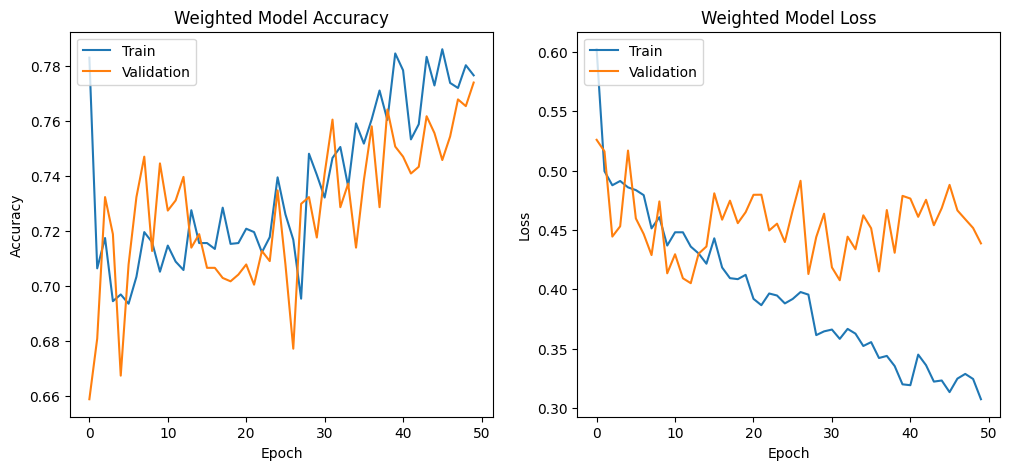

In [21]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for weighted model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_weighted.history['accuracy'])
plt.plot(history_weighted.history['val_accuracy'])
plt.title('Weighted Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for weighted model
plt.subplot(1, 2, 2)
plt.plot(history_weighted.history['loss'])
plt.plot(history_weighted.history['val_loss'])
plt.title('Weighted Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Addressing Class Imbalance with Class Weights

Given the low precision and recall, the dataset likely suffers from class imbalance. We will calculate class weights and re-train the model with these weights to give more importance to the minority class (stroke cases).

In [14]:
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:", class_weights_dict)

# Re-define and compile the model (using the same architecture)
model_weighted = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

optimizer_weighted = Adam(learning_rate=0.001)
model_weighted.compile(optimizer=optimizer_weighted,
                       loss='binary_crossentropy',
                       metrics=['accuracy', Precision(), Recall()])

print("\nTraining model with class weights...")
# Train the model with class weights
history_weighted = model_weighted.fit(X_train, y_train,
                                       epochs=50,
                                       batch_size=32,
                                       validation_split=0.2,
                                       class_weight=class_weights_dict,
                                       verbose=1)

Calculated Class Weights: {0: np.float64(0.5255849832861919), 1: np.float64(10.271356783919598)}

Training model with class weights...
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7312 - loss: 0.6043 - precision_4: 0.0893 - recall_4: 0.5197 - val_accuracy: 0.6601 - val_loss: 0.5103 - val_precision_4: 0.1356 - val_recall_4: 0.9149
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6902 - loss: 0.5021 - precision_4: 0.1139 - recall_4: 0.8355 - val_accuracy: 0.7384 - val_loss: 0.4178 - val_precision_4: 0.1647 - val_recall_4: 0.8723
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7119 - loss: 0.4939 - precision_4: 0.1187 - recall_4: 0.8092 - val_accuracy: 0.6968 - val_loss: 0.4996 - val_precision_4: 0.1498 - val_recall_4: 0.9149
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7064 - loss: 0.4736 - precision_4: 0.1189 - recall_4: 0.8289 - val_accuracy: 0.6663 - val_loss: 0.5315 - val_precision_4: 0.1378 - val_recall_4: 0.9149
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6835 - loss: 0.4909 - precision_4: 0.1117 - recall_4: 0.8355 - val_accura

### Addressing Class Imbalance with Class Weights

Given the low precision and recall, the dataset likely suffers from class imbalance. We will calculate class weights and re-train the model with these weights to give more importance to the minority class (stroke cases).

In [15]:
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:", class_weights_dict)

# Re-define and compile the model (using the same architecture)
model_weighted = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

optimizer_weighted = Adam(learning_rate=0.001)
model_weighted.compile(optimizer=optimizer_weighted,
                       loss='binary_crossentropy',
                       metrics=['accuracy', Precision(), Recall()])

print("\nTraining model with class weights...")
# Train the model with class weights
history_weighted = model_weighted.fit(X_train, y_train,
                                       epochs=50,
                                       batch_size=32,
                                       validation_split=0.2,
                                       class_weight=class_weights_dict,
                                       verbose=1)

Calculated Class Weights: {0: np.float64(0.5255849832861919), 1: np.float64(10.271356783919598)}

Training model with class weights...
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7829 - loss: 0.6023 - precision_5: 0.1048 - recall_5: 0.4868 - val_accuracy: 0.6589 - val_loss: 0.5260 - val_precision_5: 0.1375 - val_recall_5: 0.9362
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7064 - loss: 0.4995 - precision_5: 0.1145 - recall_5: 0.7895 - val_accuracy: 0.6809 - val_loss: 0.5162 - val_precision_5: 0.1433 - val_recall_5: 0.9149
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7174 - loss: 0.4877 - precision_5: 0.1193 - recall_5: 0.7961 - val_accuracy: 0.7323 - val_loss: 0.4445 - val_precision_5: 0.1614 - val_recall_5: 0.8723
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6945 - loss: 0.4913 - precision_5: 0.1167 - recall_5: 0.8487 - val_accuracy: 0.7188 - val_loss: 0.4531 - val_precision_5: 0.1599 - val_recall_5: 0.9149
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6969 - loss: 0.4859 - precision_5: 0.1210 - recall_5: 0.8816 - val_accura

### Addressing Class Imbalance with Class Weights

Given the low precision and recall, the dataset likely suffers from class imbalance. We will calculate class weights and re-train the model with these weights to give more importance to the minority class (stroke cases).

In [12]:
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:", class_weights_dict)

# Re-define and compile the model (using the same architecture)
model_weighted = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

optimizer_weighted = Adam(learning_rate=0.001)
model_weighted.compile(optimizer=optimizer_weighted,
                       loss='binary_crossentropy',
                       metrics=['accuracy', Precision(), Recall()])

print("\nTraining model with class weights...")
# Train the model with class weights
history_weighted = model_weighted.fit(X_train, y_train,
                                       epochs=50,
                                       batch_size=32,
                                       validation_split=0.2,
                                       class_weight=class_weights_dict,
                                       verbose=1)

Calculated Class Weights: {0: np.float64(0.5255849832861919), 1: np.float64(10.271356783919598)}

Training model with class weights...
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7067 - loss: 0.6054 - precision_2: 0.0904 - recall_2: 0.5855 - val_accuracy: 0.7213 - val_loss: 0.4836 - val_precision_2: 0.1610 - val_recall_2: 0.9149
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7003 - loss: 0.5142 - precision_2: 0.1138 - recall_2: 0.8026 - val_accuracy: 0.7029 - val_loss: 0.4656 - val_precision_2: 0.1500 - val_recall_2: 0.8936
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6869 - loss: 0.4937 - precision_2: 0.1148 - recall_2: 0.8553 - val_accuracy: 0.7249 - val_loss: 0.4357 - val_precision_2: 0.1577 - val_recall_2: 0.8723
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7064 - loss: 0.4849 - precision_2: 0.1210 - recall_2: 0.8487 - val_accuracy: 0.7176 - val_loss: 0.4461 - val_precision_2: 0.1541 - val_recall_2: 0.8723
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6994 - loss: 0.4740 - precision_2: 0.1199 - recall_2: 0.8618 - val_accura

### Evaluate the Weighted Model

Now, let's evaluate the performance of the model trained with class weights on the test set.

In [18]:
# Evaluate the weighted model on the test set
loss_weighted, accuracy_weighted, precision_weighted, recall_weighted = model_weighted.evaluate(X_test, y_test, verbose=0)

print(f"Weighted Model Test Loss: {loss_weighted:.4f}")
print(f"Weighted Model Test Accuracy: {accuracy_weighted:.4f}")
print(f"Weighted Model Test Precision: {precision_weighted:.4f}")
print(f"Weighted Model Test Recall: {recall_weighted:.4f}")

# Compare with previous model's results (assuming variables 'accuracy', 'precision', 'recall' are still available)
print("\n--- Comparison with Original Model ---")
print(f"Original Model Test Accuracy: {accuracy:.4f}")
print(f"Original Model Test Precision: {precision:.4f}")
print(f"Original Model Test Recall: {recall:.4f}")

Weighted Model Test Loss: 0.3943
Weighted Model Test Accuracy: 0.7877
Weighted Model Test Precision: 0.1477
Weighted Model Test Recall: 0.7000

--- Comparison with Original Model ---
Original Model Test Accuracy: 0.9413
Original Model Test Precision: 0.1875
Original Model Test Recall: 0.0600


### Visualize Weighted Model Training History

Let's also plot the training and validation loss and accuracy for the weighted model to understand its learning process.

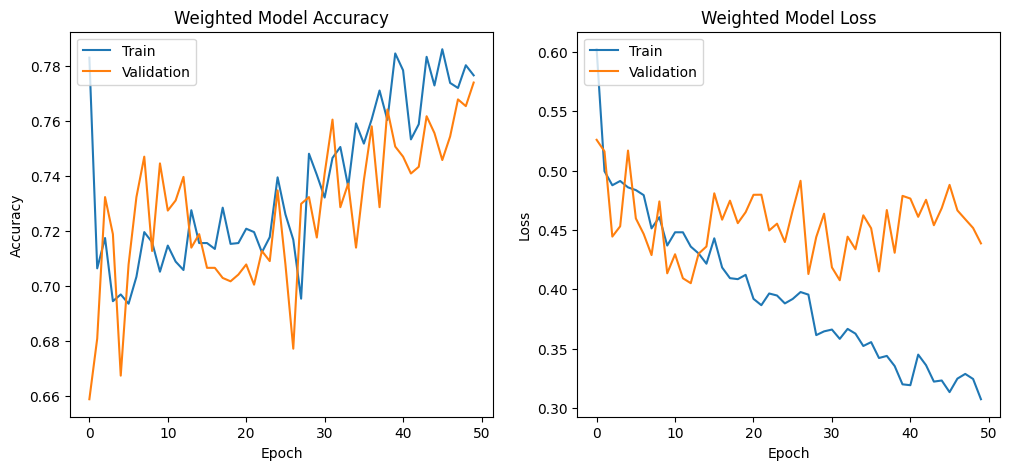

In [19]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for weighted model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_weighted.history['accuracy'])
plt.plot(history_weighted.history['val_accuracy'])
plt.title('Weighted Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for weighted model
plt.subplot(1, 2, 2)
plt.plot(history_weighted.history['loss'])
plt.plot(history_weighted.history['val_loss'])
plt.title('Weighted Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Evaluate the Weighted Model

Now, let's evaluate the performance of the model trained with class weights on the test set.

In [16]:
# Evaluate the weighted model on the test set
loss_weighted, accuracy_weighted, precision_weighted, recall_weighted = model_weighted.evaluate(X_test, y_test, verbose=0)

print(f"Weighted Model Test Loss: {loss_weighted:.4f}")
print(f"Weighted Model Test Accuracy: {accuracy_weighted:.4f}")
print(f"Weighted Model Test Precision: {precision_weighted:.4f}")
print(f"Weighted Model Test Recall: {recall_weighted:.4f}")

# Compare with previous model's results (assuming variables 'accuracy', 'precision', 'recall' are still available)
print("\n--- Comparison with Original Model ---")
print(f"Original Model Test Accuracy: {accuracy:.4f}")
print(f"Original Model Test Precision: {precision:.4f}")
print(f"Original Model Test Recall: {recall:.4f}")

Weighted Model Test Loss: 0.3943
Weighted Model Test Accuracy: 0.7877
Weighted Model Test Precision: 0.1477
Weighted Model Test Recall: 0.7000

--- Comparison with Original Model ---
Original Model Test Accuracy: 0.9413
Original Model Test Precision: 0.1875
Original Model Test Recall: 0.0600


### Visualize Weighted Model Training History

Let's also plot the training and validation loss and accuracy for the weighted model to understand its learning process.

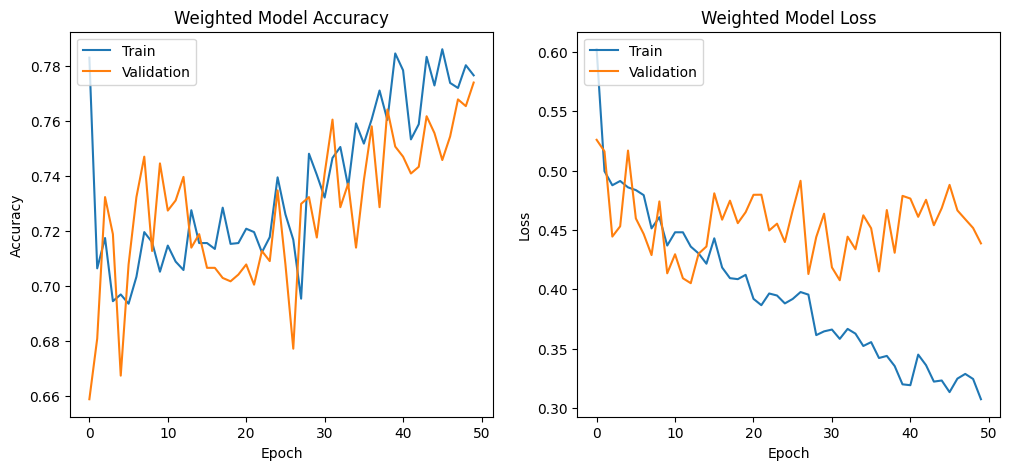

In [17]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for weighted model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_weighted.history['accuracy'])
plt.plot(history_weighted.history['val_accuracy'])
plt.title('Weighted Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for weighted model
plt.subplot(1, 2, 2)
plt.plot(history_weighted.history['loss'])
plt.plot(history_weighted.history['val_loss'])
plt.title('Weighted Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Create a Streamlit Application

Now, let's create a simple Streamlit application to demonstrate how to use the trained model for predictions. This will allow for interactive input and prediction output.

In [24]:
# Install Streamlit (if not already installed)
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 72.0 MB/s eta 0:00:00


To create the Streamlit app, we need to save the model and the scaler. Then, we will create an `app.py` file that loads these artifacts and provides input fields for prediction.

In [25]:
import joblib

# Save the trained weighted model
model_weighted.save('stroke_prediction_model_weighted.h5')
print('Weighted model saved as stroke_prediction_model_weighted.h5')

# Save the StandardScaler fitted on X_train
joblib.dump(scaler, 'scaler.pkl')
print('Scaler saved as scaler.pkl')

# Also save a list of columns for consistent feature ordering
import pandas as pd
import numpy as np

# Re-create the X_train to get column names consistently
# Drop the 'gender_Other' column if it exists, as it often has very few samples and can cause issues
if 'gender_Other' in df.columns:
    df_temp = df.drop('gender_Other', axis=1)
else:
    df_temp = df.copy()

X_temp = df_temp.drop('stroke', axis=1)
feature_columns = X_temp.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')
print('Feature columns saved as feature_columns.pkl')

Weighted model saved as stroke_prediction_model_weighted.h5
Scaler saved as scaler.pkl
Feature columns saved as feature_columns.pkl


In [36]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib
import os # To check for file existence

# Set Streamlit page configuration
st.set_page_config(
    page_title="Stroke Prediction App",
    page_icon="🧠",
    layout="centered",
    initial_sidebar_state="expanded"
)

# Load the trained model
@st.cache_resource
def load_model():
    model_path = 'stroke_prediction_model_weighted.h5'
    if not os.path.exists(model_path):
        st.error(f"Model file not found: {model_path}. Please ensure it's in the same directory.")
        return None
    try:
        # Suppress the Keras UserWarning about legacy HDF5 format during loading
        with tf.keras.utils.custom_object_scope({}): # Use a temporary scope if there were custom objects saved
            model = tf.keras.models.load_model(model_path)
        return model
    except Exception as e:
        st.error(f"Error loading model: {e}")
        return None

# Load the scaler
@st.cache_resource
def load_scaler():
    scaler_path = 'scaler.pkl'
    if not os.path.exists(scaler_path):
        st.error(f"Scaler file not found: {scaler_path}. Please ensure it's in the same directory.")
        return None
    try:
        scaler = joblib.load(scaler_path)
        return scaler
    except Exception as e:
        st.error(f"Error loading scaler: {e}")
        return None

# Load feature columns
@st.cache_resource
def load_feature_columns():
    features_path = 'feature_columns.pkl'
    if not os.path.exists(features_path):
        st.error(f"Feature columns file not found: {features_path}. Please ensure it's in the same directory.")
        return None
    try:
        feature_columns = joblib.load(features_path)
        return feature_columns
    except Exception as e:
        st.error(f"Error loading feature columns: {e}")
        return None

model = load_model()
scaler = load_scaler()
feature_columns = load_feature_columns()

# Stop the app if any essential component failed to load
if model is None or scaler is None or feature_columns is None:
    st.stop()


# --- Sidebar for Input Panel ---
st.sidebar.title("🧠 Stroke Risk Predictor")
st.sidebar.markdown("--- ✨ User Input ✨ ---")
st.sidebar.markdown("Adjust the parameters below to get a real-time stroke risk prediction.")

# Input fields for patient data (moved to sidebar)
with st.sidebar:
    st.markdown("### Demographics & Lifestyle")
    gender = st.selectbox('🚻 Gender', ['Female', 'Male'])
    age = st.slider('👴 Age', 0, 100, 45)
    ever_married = st.selectbox('💍 Ever Married', ['Yes', 'No'])
    work_type = st.selectbox('💼 Work Type', ['Private', 'Self-employed', 'children', 'Govt_job', 'Never_worked'])
    residence_type = st.selectbox('🏡 Residence Type', ['Urban', 'Rural'])
    smoking_status = st.selectbox('🚬 Smoking Status', ['formerly smoked', 'never smoked', 'smokes', 'Unknown'])

    st.markdown("### Medical Information")
    hypertension = st.radio('🩸 Hypertension', [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No', horizontal=True)
    heart_disease = st.radio('🫀 Heart Disease', [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No', horizontal=True)
    avg_glucose_level = st.number_input('🍬 Average Glucose Level', 50.0, 300.0, 100.0, step=0.1)
    bmi = st.number_input('⚖️ BMI', 10.0, 60.0, 25.0, step=0.1)

    st.markdown("--- ")
    predict_button = st.button('🚀 Predict Stroke Risk')

# --- Main Content Area ---
st.markdown("## Comprehensive Stroke Risk Assessment")
st.markdown("""
Welcome to the **Stroke Risk Prediction application**. This tool uses a deep learning model to estimate the likelihood of a stroke based on various health and lifestyle factors.

Please use the **input panel on the left** to enter the patient's details. The model will then calculate and display the predicted stroke probability.
""")
st.info("💡 **Important:** This model is trained to have a high recall for stroke cases, aiming to reduce false negatives. However, it is a predictive tool and **not a substitute for professional medical advice**. Always consult with a qualified healthcare provider for any health concerns.")

# Preprocess function
def preprocess_input(data):
    # Create a DataFrame from input data
    input_df = pd.DataFrame([data])

    # Create a dummy DataFrame with all possible columns to ensure consistency
    # This is crucial for matching the training data's one-hot encoded structure
    all_columns_template = pd.DataFrame(0, index=[0], columns=feature_columns)

    # Manual one-hot encoding logic to ensure consistency with `drop_first=True`
    # Gender (assuming 'Female' is base, 'gender_Male' is the column if it exists in feature_columns)
    if 'gender_Male' in feature_columns and data['gender'] == 'Male':
        all_columns_template['gender_Male'] = 1

    # Ever_married
    if 'ever_married_Yes' in feature_columns and data['ever_married'] == 'Yes':
        all_columns_template['ever_married_Yes'] = 1

    # Work_type
    if f"work_type_{data['work_type']}" in feature_columns:
        all_columns_template[f"work_type_{data['work_type']}"] = 1

    # Residence_type
    # Corrected: Access 'Residence_type' with correct casing
    if f"Residence_type_{data['Residence_type']}" in feature_columns:
        all_columns_template[f"Residence_type_{data['Residence_type']}"] = 1

    # Smoking_status
    if f"smoking_status_{data['smoking_status']}" in feature_columns:
        all_columns_template[f"smoking_status_{data['smoking_status']}"] = 1

    # Assign numerical values
    all_columns_template['age'] = data['age']
    all_columns_template['hypertension'] = data['hypertension']
    all_columns_template['heart_disease'] = data['heart_disease']
    all_columns_template['avg_glucose_level'] = data['avg_glucose_level']
    all_columns_template['bmi'] = data['bmi']

    # Ensure the order of columns matches the training data features
    # Convert to numpy array for model prediction (Keras models expect numpy arrays)
    processed_input = all_columns_template[feature_columns].values

    return processed_input

if predict_button:
    patient_data = {
        'gender': gender,
        'age': age,
        'hypertension': hypertension,
        'heart_disease': heart_disease,
        'ever_married': ever_married,
        'work_type': work_type,
        'Residence_type': residence_type,
        'avg_glucose_level': avg_glucose_level,
        'bmi': bmi,
        'smoking_status': smoking_status
    }

    try:
        processed_data = preprocess_input(patient_data)
        prediction = model.predict(processed_data)[0][0]

        st.markdown("### 📊 Prediction Result")
        st.write(f"Based on the provided information, the model predicts a stroke probability of: **{prediction*100:.2f}%**")

        if prediction > 0.5: # Threshold for binary classification
            st.error(f'⚠️ **High risk of stroke!** Consider consulting a medical professional immediately.')
        else:
            st.success(f'✅ **Low risk of stroke.** Continue to maintain a healthy lifestyle.')

        st.markdown("""
        ---
        ### How to interpret the result:
        - **High risk (red box):** The model predicts a higher likelihood of stroke. It's recommended to seek medical advice.
        - **Low risk (green box):** The model predicts a lower likelihood of stroke. Maintain a healthy lifestyle and regular check-ups.
        """)
        st.write("Disclaimer: This is a predictive model result and should not replace professional medical advice. Always consult with a qualified healthcare provider for any health concerns.")

    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")


Overwriting app.py


### Run the Streamlit App

To run the Streamlit app, execute the following command in a new cell. This will provide a public URL to view and interact with your application.

```bash
!streamlit run app.py & npx localtunnel --port 8501
```

Click on the `External URL` provided in the output to open your Streamlit application in a new browser tab.

To stop the Streamlit app, interrupt the kernel.

In [27]:
!pip install --ignore-installed blinker
!pip install streamlit

In [28]:
!pip install streamlit pyngrok

In [29]:
from pyngrok import ngrok
ngrok.set_auth_token("3H2nxZtP4iC5L9tX9K97OPLut9W_4JsZrRVF5aRFQpQCCePy1")

In [37]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:8501"


In [38]:
# Run the Streamlit app
# This will provide a public URL to access the app
!streamlit run app.py &


2026-08-24 13:22:27.078 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.53.60.209:8501

2026-08-24 13:22:35.344651: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
  Stopping...


### Data Preprocessing

Based on the `df.info()` output, we have:
- Missing values in the `bmi` column.
- Several categorical columns: `gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`.
- An `id` column which is not useful for training.

In [4]:
# Drop the 'id' column as it is not a feature
df = df.drop('id', axis=1)

# Handle missing values in 'bmi' by imputing with the mean
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

# Check for unique values in categorical columns to identify any anomalies, especially 'gender'
print("Unique values for 'gender':", df['gender'].unique())

# Handle the 'Other' gender category if it exists and is problematic (e.g., very few samples)
# For simplicity, if 'Other' exists and has very few samples, we might drop it or map it to a more common category.
# Let's inspect the value counts first
print("Gender value counts:\n", df['gender'].value_counts())

# If 'Other' gender category exists and is negligible, we can remove it or re-map it.
# For now, we will proceed assuming 'Other' is not a significant issue or will be handled by one-hot encoding.

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('stroke') # 'stroke' is our target variable

# Apply one-hot encoding to categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the preprocessed DataFrame
display(df.head())

# Display the info of the preprocessed DataFrame to confirm changes
display(df.info())

Unique values for 'gender': ['Male' 'Female' 'Other']
Gender value counts:
 gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


/tmp/ipykernel_2181/1645311821.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.600000,1,True,False,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.893237,1,False,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.500000,1,True,False,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.400000,1,False,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.000000,1,False,False,True,False,False,True,False,False,False,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             5110 non-null   float64
 1   hypertension                    5110 non-null   int64  
 2   heart_disease                   5110 non-null   int64  
 3   avg_glucose_level               5110 non-null   float64
 4   bmi                             5110 non-null   float64
 5   stroke                          5110 non-null   int64  
 6   gender_Male                     5110 non-null   bool   
 7   gender_Other                    5110 non-null   bool   
 8   ever_married_Yes                5110 non-null   bool   
 9   work_type_Never_worked          5110 non-null   bool   
 10  work_type_Private               5110 non-null   bool   
 11  work_type_Self-employed         5110 non-null   bool   
 12  work_type_children              51

None